# Step-34: Low-Turnover Periodic Rebalancing (Execution Optimization)

## Financial Market Trend Forecasting Using Ensemble Learning and Deep Sequence Models

This notebook optimizes **deployment and execution**, not alpha generation.  
The Step-28 alpha signal is treated as fixed. The goal is to mitigate turnover destruction observed in Step-33.


## Leakage-Safe Backtesting Protocol

This notebook enforces strict chronological integrity:

1. `pred_score[t]` is transformed into weights **at time t**.
2. Realized portfolio return at date `t` uses **previous-period weights** (`weight[t-1]`).
3. We never multiply same-row signal and same-row newly-formed weight.
4. Transaction costs are applied only on weight changes (turnover).
5. Volatility estimates for inverse-vol weighting use shifted history only.

This preserves purged temporal logic and avoids lookahead leakage.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 260)

CFG = {
    "start_date": "2023-01-01",
    "end_date": "2026-01-01",
    "signal_ema_halflife": 5,
    "long_threshold": 0.75,
    "short_threshold": 0.25,
    "max_long_positions": 10,
    "max_short_positions": 10,
    "max_single_weight": 0.10,
    "target_gross_exposure": 1.0,
    "rebal_frequency": 3,
    "min_holding_days": 3,
    "max_net_exposure": 0.10,
    "target_volatility": 0.18,
    "transaction_cost_bps": 20.0,
    "slippage_bps": 5.0,
    "allowed_regimes": ["HIGH", "MEDIUM"],
    "vol_lookback": 40,
    "annualization_days": 252,
    "vol_scale_min": 0.6,
    "vol_scale_max": 1.4,
}


def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for p in [cwd, cwd.parent, cwd.parent.parent]:
        if (p / "ml_pipeline").exists():
            return p
    raise FileNotFoundError("Project root not found.")


ROOT = resolve_project_root()
BASE = ROOT / "ml_pipeline"
FINAL_DIR = BASE / "Market_Data" / "final"
PROC_DIR = BASE / "Market_Data" / "processed"

STEP28_PATH = FINAL_DIR / "cross_sectional_alpha_results.parquet"
STEP33_PATH = FINAL_DIR / "step33_cost_aware_portfolio.parquet"
FINAL_MODEL_PATH = PROC_DIR / "final_model_dataset.parquet"

OUT_PORT = FINAL_DIR / "step34_low_turnover_portfolio.parquet"
OUT_IC = FINAL_DIR / "step34_ic_comparison.csv"
OUT_TURN = FINAL_DIR / "step34_turnover_analysis.csv"
OUT_SUM = FINAL_DIR / "step34_summary.csv"

assert STEP28_PATH.exists(), f"Missing {STEP28_PATH}"


In [2]:
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    cmap = {}
    for c in df.columns:
        cl = c.lower()
        if cl == "date":
            cmap[c] = "date"
        elif cl == "ticker":
            cmap[c] = "ticker"
        elif cl in {"pred_score", "pred_lightgbmregressor", "pred_final"} and "pred_score" not in cmap.values():
            cmap[c] = "pred_score"
        elif cl in {"actual_return", "target_future_return_t3"} and "actual_return" not in cmap.values():
            cmap[c] = "actual_return"
        elif cl == "regime":
            cmap[c] = "regime"
    out = df.rename(columns=cmap).copy()
    req = ["date", "ticker", "pred_score", "actual_return"]
    miss = [c for c in req if c not in out.columns]
    if miss:
        raise ValueError(f"Missing required columns: {miss}")
    if "regime" not in out.columns:
        out["regime"] = np.nan
    return out


raw = pd.read_parquet(STEP28_PATH)
df = standardize_columns(raw)
df["date"] = pd.to_datetime(df["date"])
df = df[(df["date"] >= pd.Timestamp(CFG["start_date"])) & (df["date"] <= pd.Timestamp(CFG["end_date"]))].copy()
df["ticker"] = df["ticker"].astype(str)
df = df.sort_values(["ticker", "date"]).drop_duplicates(["date", "ticker"]).reset_index(drop=True)

if df["regime"].isna().all():
    fm = pd.read_parquet(FINAL_MODEL_PATH, columns=["Date", "Ticker", "Volatility_20"]).rename(columns={"Date": "date", "Ticker": "ticker"})
    fm["date"] = pd.to_datetime(fm["date"])
    tr = fm[(fm["date"] >= pd.Timestamp("2023-01-01")) & (fm["date"] <= pd.Timestamp("2024-12-31"))]["Volatility_20"].dropna()
    q1, q2 = tr.quantile(1 / 3), tr.quantile(2 / 3)
    fm["regime"] = np.where(fm["Volatility_20"] <= q1, "LOW", np.where(fm["Volatility_20"] <= q2, "MEDIUM", "HIGH"))
    df = df.drop(columns=["regime"]).merge(fm[["date", "ticker", "regime"]], on=["date", "ticker"], how="left")

df["regime"] = df["regime"].astype(str).str.upper().fillna("MEDIUM")

# Shifted volatility proxy for inverse-vol weighting
df["vol_est"] = (
    df.sort_values(["ticker", "date"])
    .groupby("ticker")["actual_return"]
    .transform(lambda s: s.rolling(CFG["vol_lookback"], min_periods=5).std().shift(1))
)
df["vol_est"] = df["vol_est"].replace(0, np.nan)
df["vol_est"] = df["vol_est"].fillna(df["vol_est"].median()).fillna(0.02)
df["inv_vol"] = 1.0 / df["vol_est"].clip(lower=1e-6)

# Deployment-layer smoothing (no alpha redesign)
df["pred_score_smooth"] = (
    df.sort_values(["ticker", "date"])
    .groupby("ticker")["pred_score"]
    .transform(lambda s: s.ewm(halflife=CFG["signal_ema_halflife"], adjust=False).mean())
)
df["rank_raw"] = df.groupby("date")["pred_score"].rank(pct=True, method="average")
df["rank_smooth"] = df.groupby("date")["pred_score_smooth"].rank(pct=True, method="average")

print("Prepared frame:", df.shape)
display(df.head(8))


Prepared frame: (4900, 21)


,ticker,date,actual_return,target_rank_cs,target_zscore_cs,pred_XGBoostRegressor,pred_score,side,weight,portfolio_return_component,daily_portfolio_return,model_selected,ic_mean_selected,ic_std_selected,sharpe_selected,regime,vol_est,inv_vol,pred_score_smooth,rank_raw,rank_smooth
0,ABB,2025-01-02,-0.026916,0.479167,-0.249188,0.009419,0.015437,1,0.1,-0.002692,-0.002077,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.031946,31.302939,0.015437,0.90,0.95
1,ABB,2025-01-03,-0.021051,0.583333,0.162705,0.012527,0.028985,1,0.1,-0.002105,0.006111,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.031946,31.302939,0.017190,1.00,0.70
2,ABB,2025-01-06,-0.020822,0.343750,-0.446947,0.011315,0.035563,1,0.1,-0.002082,-0.014862,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.031946,31.302939,0.019569,0.95,0.65
3,ABB,2025-01-08,-0.082282,0.270833,-0.729417,0.010574,0.020480,1,0.1,-0.008228,-0.020856,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.031946,31.302939,0.019687,0.85,0.85
4,ABB,2025-01-09,-0.051809,0.187500,-0.766272,0.013038,0.023781,1,0.1,-0.005181,-0.009316,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.031946,31.302939,0.020217,0.80,0.85
5,ABB,2025-01-13,0.032574,0.541667,-0.052060,-0.008812,0.009896,1,0.1,0.003257,-0.001118,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.026569,37.638312,0.018881,0.90,0.85
6,ABB,2025-01-14,0.061969,0.937500,1.430968,0.010845,0.040337,1,0.1,0.006197,0.006977,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.038164,26.202369,0.021658,0.90,0.80
7,ABB,2025-01-15,0.053522,0.885417,1.070829,0.006853,0.012827,1,0.1,0.005352,0.032825,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.048786,20.497874,0.020515,0.75,0.95


## Raw vs Smoothed Signal Quality Validation

We compare:
- rank consistency (cross-sectional Spearman between raw and smoothed ranks),
- daily IC using raw score vs smoothed score.

Automatic warning is raised if smoothing causes material IC damage.


In [3]:
def daily_ic(in_df: pd.DataFrame, signal_col: str, ret_col: str = "actual_return", min_names: int = 10) -> pd.DataFrame:
    rows = []
    for dt, g in in_df.groupby("date", sort=True):
        d = g[[signal_col, ret_col]].dropna()
        if len(d) < min_names:
            continue
        rho, _ = spearmanr(d[signal_col], d[ret_col])
        if pd.notna(rho):
            rows.append({"date": dt, "ic": float(rho)})
    return pd.DataFrame(rows).sort_values("date").reset_index(drop=True)


# rank correlation raw vs smoothed
rank_corr_rows = []
for dt, g in df.groupby("date", sort=True):
    d = g[["rank_raw", "rank_smooth"]].dropna()
    if len(d) < 10:
        continue
    rho, _ = spearmanr(d["rank_raw"], d["rank_smooth"])
    if pd.notna(rho):
        rank_corr_rows.append({"date": dt, "rank_corr": float(rho)})
rank_corr_df = pd.DataFrame(rank_corr_rows)
avg_rank_corr = float(rank_corr_df["rank_corr"].mean()) if len(rank_corr_df) else np.nan

ic_raw_df = daily_ic(df, "pred_score", "actual_return")
ic_smooth_df = daily_ic(df, "pred_score_smooth", "actual_return")

mean_ic_raw = float(ic_raw_df["ic"].mean()) if len(ic_raw_df) else np.nan
mean_ic_smooth = float(ic_smooth_df["ic"].mean()) if len(ic_smooth_df) else np.nan
ic_delta = mean_ic_smooth - mean_ic_raw if pd.notna(mean_ic_raw) and pd.notna(mean_ic_smooth) else np.nan

ic_comp = pd.DataFrame(
    [
        {"metric": "avg_rank_corr_raw_vs_smooth", "value": avg_rank_corr},
        {"metric": "mean_ic_raw", "value": mean_ic_raw},
        {"metric": "mean_ic_smoothed", "value": mean_ic_smooth},
        {"metric": "ic_delta_smoothed_minus_raw", "value": ic_delta},
    ]
)
display(ic_comp)

if pd.notna(ic_delta) and ic_delta < -0.003:
    print("WARNING: EMA smoothing materially degrades IC. Consider lower smoothing half-life.")


,metric,value
0,avg_rank_corr_raw_vs_smooth,0.620641
1,mean_ic_raw,0.026841
2,mean_ic_smoothed,0.014243
3,ic_delta_smoothed_minus_raw,-0.012598


## LowTurnoverEngine (Periodic Rebalancing + Holding)

Execution model:
- rebalance only on schedule (default every 3 trading days),
- maintain positions between rebalance dates,
- enforce minimum holding horizon,
- apply net exposure control and target gross exposure,
- compute costs from turnover.


In [4]:
@dataclass
class DailyState:
    date: pd.Timestamp
    gross_return: float
    net_return: float
    turnover: float
    tx_cost: float
    gross_leverage: float
    net_exposure: float
    is_rebalance_day: int


class LowTurnoverEngine:
    def __init__(self, cfg: dict):
        self.cfg = cfg
        self.prev_w: Dict[str, float] = {}
        self.ret_hist: List[float] = []
        self.last_rebal_idx: int = -10**9
        self.daily_rows: List[dict] = []
        self.pos_rows: List[dict] = []

    def regime_filter(self, g: pd.DataFrame) -> pd.DataFrame:
        return g[g["regime"].isin(self.cfg["allowed_regimes"])].copy()

    def select_candidates(self, g: pd.DataFrame) -> pd.DataFrame:
        longs = g[g["rank_smooth"] >= self.cfg["long_threshold"]].sort_values("rank_smooth", ascending=False).head(self.cfg["max_long_positions"])
        shorts = g[g["rank_smooth"] <= self.cfg["short_threshold"]].sort_values("rank_smooth", ascending=True).head(self.cfg["max_short_positions"])
        picks = pd.concat([longs, shorts], ignore_index=True)
        return picks.drop_duplicates(subset=["ticker"], keep="first")

    def inverse_vol_weights(self, picks: pd.DataFrame) -> Dict[str, float]:
        if len(picks) == 0:
            return {}
        p = picks.copy()
        p["side"] = np.where(p["rank_smooth"] >= 0.5, 1, -1)
        w = {}
        l = p[p["side"] == 1]
        s = p[p["side"] == -1]
        if len(l):
            a = l["inv_vol"].clip(lower=1e-8)
            a = a / a.sum()
            for t, x in zip(l["ticker"], a):
                w[t] = 0.5 * float(x)
        if len(s):
            a = s["inv_vol"].clip(lower=1e-8)
            a = a / a.sum()
            for t, x in zip(s["ticker"], a):
                w[t] = -0.5 * float(x)
        return self.normalize_exposure(w)

    def normalize_exposure(self, w: Dict[str, float]) -> Dict[str, float]:
        if not w:
            return {}
        cap = self.cfg["max_single_weight"]
        w = {k: float(np.clip(v, -cap, cap)) for k, v in w.items()}

        gross = sum(abs(v) for v in w.values())
        if gross > 0:
            scale = self.cfg["target_gross_exposure"] / gross
            w = {k: v * scale for k, v in w.items()}

        net = sum(w.values())
        max_net = self.cfg["max_net_exposure"]
        if abs(net) > max_net:
            sign = np.sign(net)
            side = [k for k, v in w.items() if np.sign(v) == sign and abs(v) > 0]
            denom = sum(abs(w[k]) for k in side)
            if denom > 0:
                adjust = abs(net) - max_net
                for k in side:
                    w[k] = w[k] - sign * adjust * (abs(w[k]) / denom)
        return w

    def turnover(self, old_w: Dict[str, float], new_w: Dict[str, float]) -> float:
        keys = set(old_w) | set(new_w)
        return float(sum(abs(new_w.get(k, 0.0) - old_w.get(k, 0.0)) for k in keys))

    def tx_cost(self, turnover: float, tx_bps: float | None = None) -> float:
        tx = self.cfg["transaction_cost_bps"] if tx_bps is None else tx_bps
        all_in = (tx + self.cfg["slippage_bps"]) / 10000.0
        return float(all_in * turnover)

    def run(self, in_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
        dates = sorted(in_df["date"].unique())
        for i, dt in enumerate(dates):
            g_all = in_df[in_df["date"] == dt].copy()

            # Execution lag: today's return uses yesterday's weights.
            ret_map = dict(zip(g_all["ticker"], g_all["actual_return"]))
            gross_ret = float(sum(self.prev_w.get(t, 0.0) * ret_map.get(t, 0.0) for t in self.prev_w))

            rebal_sched = (i % self.cfg["rebal_frequency"] == 0)
            hold_ok = ((i - self.last_rebal_idx) >= self.cfg["min_holding_days"])
            do_rebal = bool(rebal_sched and hold_ok)

            target_w = self.prev_w.copy()
            to = 0.0
            if do_rebal:
                g = self.regime_filter(g_all)
                picks = self.select_candidates(g)
                target_w = self.inverse_vol_weights(picks)
                to = self.turnover(self.prev_w, target_w)
                self.last_rebal_idx = i

            cost = self.tx_cost(to)
            net_ret = gross_ret - cost

            gross_lev = float(sum(abs(v) for v in self.prev_w.values()))
            net_exp = float(sum(self.prev_w.values()))

            self.daily_rows.append(
                {
                    "date": pd.Timestamp(dt),
                    "gross_return": gross_ret,
                    "net_return": net_ret,
                    "turnover": to,
                    "tx_cost": cost,
                    "gross_leverage": gross_lev,
                    "net_exposure": net_exp,
                    "is_rebalance_day": int(do_rebal),
                }
            )

            # position level record
            all_tickers = set(g_all["ticker"].tolist()) | set(self.prev_w.keys()) | set(target_w.keys())
            g_map = g_all.set_index("ticker")[["regime", "pred_score", "pred_score_smooth", "rank_raw", "rank_smooth", "actual_return"]].to_dict("index")
            for t in all_tickers:
                rr = g_map.get(t, {})
                self.pos_rows.append(
                    {
                        "date": pd.Timestamp(dt),
                        "ticker": t,
                        "regime": rr.get("regime", np.nan),
                        "pred_score": rr.get("pred_score", np.nan),
                        "pred_score_smooth": rr.get("pred_score_smooth", np.nan),
                        "rank_raw": rr.get("rank_raw", np.nan),
                        "rank_smooth": rr.get("rank_smooth", np.nan),
                        "actual_return": rr.get("actual_return", np.nan),
                        "weight_exec": self.prev_w.get(t, 0.0),
                        "weight_target": target_w.get(t, self.prev_w.get(t, 0.0)),
                        "position_pnl_component": self.prev_w.get(t, 0.0) * rr.get("actual_return", 0.0),
                    }
                )

            self.ret_hist.append(net_ret)
            self.prev_w = {k: v for k, v in target_w.items() if abs(v) > 1e-12}

        daily = pd.DataFrame(self.daily_rows).sort_values("date").reset_index(drop=True)
        pos = pd.DataFrame(self.pos_rows).sort_values(["date", "ticker"]).reset_index(drop=True)
        return daily, pos


In [5]:
def sharpe(s: pd.Series, ann: int = 252) -> float:
    x = s.dropna()
    if len(x) < 2:
        return np.nan
    sd = x.std(ddof=1)
    if sd == 0 or pd.isna(sd):
        return np.nan
    return float(np.sqrt(ann) * x.mean() / sd)


def perf_metrics(daily: pd.DataFrame, ann: int = 252) -> pd.DataFrame:
    r = daily["net_return"].fillna(0)
    tr = float((1 + r).prod() - 1)
    yrs = max((daily["date"].max() - daily["date"].min()).days / 365.25, 1e-9)
    cagr = float((1 + tr) ** (1 / yrs) - 1) if tr > -1 else np.nan
    vol = float(r.std(ddof=1) * np.sqrt(ann)) if len(r) > 1 else np.nan
    sh = sharpe(r, ann)
    eq = (1 + r).cumprod()
    dd = eq / eq.cummax() - 1
    mdd = float(dd.min()) if len(dd) else np.nan
    calmar = float(cagr / abs(mdd)) if pd.notna(mdd) and mdd < 0 else np.nan
    return pd.DataFrame(
        [
            ("Total Return", tr),
            ("Annualized Return", cagr),
            ("Annualized Volatility", vol),
            ("Sharpe Ratio", sh),
            ("Max Drawdown", mdd),
            ("Calmar Ratio", calmar),
            ("Win Rate", float((r > 0).mean())),
            ("Average Turnover", float(daily["turnover"].mean())),
            ("Average Gross Leverage", float(daily["gross_leverage"].mean())),
            ("Average Net Exposure", float(daily["net_exposure"].mean())),
            ("Total Transaction Cost", float(daily["tx_cost"].sum())),
        ],
        columns=["Metric", "Value"],
    )


engine = LowTurnoverEngine(CFG)
daily_df, pos_df = engine.run(df)
display(daily_df.head())
display(pos_df.head())

# leakage checks
assert daily_df["date"].is_monotonic_increasing, "Date order broken."
assert abs(daily_df.loc[daily_df.index[0], "gross_return"]) < 1e-12, "First day gross return must be zero due to execution lag."
print("Leakage checks passed.")


,date,gross_return,net_return,turnover,tx_cost,gross_leverage,net_exposure,is_rebalance_day
0,2025-01-01,0.000000,-0.002125,0.850000,0.002125,0.000000,0.0,1
1,2025-01-02,-0.002069,-0.002069,0.000000,0.000000,0.850000,0.1,0
2,2025-01-03,-0.004222,-0.004222,0.000000,0.000000,0.850000,0.1,0
3,2025-01-06,0.001073,-0.002088,1.264286,0.003161,0.850000,0.1,1
4,2025-01-07,-0.012802,-0.012802,0.000000,0.000000,0.671429,0.1,0


,date,ticker,regime,pred_score,pred_score_smooth,rank_raw,rank_smooth,actual_return,weight_exec,weight_target,position_pnl_component
0,2025-01-01,ADANIENT,HIGH,0.023142,0.023142,0.95,0.95,-0.031470,0.0,0.079167,-0.0
1,2025-01-01,ADANIPORTS,MEDIUM,0.009093,0.009093,0.60,0.60,-0.045663,0.0,0.000000,-0.0
2,2025-01-01,ADANIPOWER,HIGH,0.009626,0.009626,0.80,0.80,-0.053831,0.0,0.079167,-0.0
3,2025-01-01,AMBUJACEM,LOW,-0.005614,-0.005614,0.30,0.30,-0.016153,0.0,0.000000,-0.0
4,2025-01-01,BAJAJHLDNG,HIGH,0.036119,0.036119,1.00,1.00,-0.068998,0.0,0.079167,-0.0


Leakage checks passed.


In [6]:
# Rebalance-day vs hold-day diagnostics
reb = daily_df[daily_df["is_rebalance_day"] == 1]["net_return"]
hold = daily_df[daily_df["is_rebalance_day"] == 0]["net_return"]
reb_sh = sharpe(reb, CFG["annualization_days"])
hold_sh = sharpe(hold, CFG["annualization_days"])

regime_diag_rows = []
for reg in ["HIGH", "MEDIUM", "LOW"]:
    reg_daily = (
        pos_df[pos_df["regime"] == reg]
        .groupby("date", as_index=True)["position_pnl_component"]
        .sum()
        .reindex(daily_df["date"])
        .fillna(0.0)
    )
    regime_diag_rows.append(
        {
            "regime": reg,
            "sharpe": sharpe(reg_daily, CFG["annualization_days"]),
            "mean_daily_return": float(reg_daily.mean()),
        }
    )
regime_diag = pd.DataFrame(regime_diag_rows)
display(regime_diag.round(6))

# turnover comparison vs step-33
step33_turn = np.nan
if STEP33_PATH.exists():
    s33 = pd.read_parquet(STEP33_PATH)
    if "turnover" in s33.columns:
        dcol = "date" if "date" in s33.columns else "Date"
        if dcol in s33.columns:
            s33[dcol] = pd.to_datetime(s33[dcol])
            step33_turn = float(s33.groupby(dcol)["turnover"].mean().mean())

step34_turn = float(daily_df["turnover"].mean())
turnover_reduction_pct = float((step33_turn - step34_turn) / step33_turn) if pd.notna(step33_turn) and step33_turn > 0 else np.nan

turnover_analysis = pd.DataFrame(
    [
        {"metric": "step33_avg_turnover", "value": step33_turn},
        {"metric": "step34_avg_turnover", "value": step34_turn},
        {"metric": "turnover_reduction_pct", "value": turnover_reduction_pct},
        {"metric": "target_lt_10pct_met", "value": float(step34_turn < 0.10)},
        {"metric": "rebalance_day_sharpe", "value": reb_sh},
        {"metric": "hold_day_sharpe", "value": hold_sh},
    ]
)
display(turnover_analysis)


,regime,sharpe,mean_daily_return
0,HIGH,0.251372,0.000101
1,MEDIUM,2.007224,0.000578
2,LOW,1.530519,0.000290


,metric,value
0,step33_avg_turnover,0.288477
1,step34_avg_turnover,0.394405
2,turnover_reduction_pct,-0.367197
3,target_lt_10pct_met,0.000000
4,rebalance_day_sharpe,-4.991451
5,hold_day_sharpe,2.132878


In [7]:
# Transaction-cost stress testing
stress_rows = []
for tx in [10, 20, 30, 50, 75, 100]:
    all_in = (tx + CFG["slippage_bps"]) / 10000.0
    r = daily_df["gross_return"] - all_in * daily_df["turnover"]
    stress_rows.append(
        {
            "tx_bps": tx,
            "total_return": float((1 + r).prod() - 1),
            "sharpe": sharpe(r, CFG["annualization_days"]),
        }
    )
stress_df = pd.DataFrame(stress_rows)
display(stress_df.round(6))


,tx_bps,total_return,sharpe
0,10,0.087925,0.722142
1,20,-0.012473,-0.030705
2,30,-0.103718,-0.761993
3,50,-0.261971,-2.127277
4,75,-0.421503,-3.602725
5,100,-0.546908,-4.805808


In [8]:
def read_series(path: Path, date_candidates: List[str], ret_candidates: List[str]) -> pd.Series:
    if not path.exists():
        return pd.Series(dtype=float)
    x = pd.read_parquet(path)
    dc = next((c for c in date_candidates if c in x.columns), None)
    rc = next((c for c in ret_candidates if c in x.columns), None)
    if dc is None or rc is None:
        return pd.Series(dtype=float)
    x[dc] = pd.to_datetime(x[dc])
    return x.groupby(dc, as_index=True)[rc].sum().sort_index()


step20 = read_series(FINAL_DIR / "validated_strategy_results.parquet", ["date", "Date"], ["net_return", "daily_strategy_return", "daily_portfolio_return"])
step24 = read_series(FINAL_DIR / "final_strategy_results.parquet", ["date", "Date"], ["net_return", "daily_strategy_return", "daily_portfolio_return"])
step28 = read_series(FINAL_DIR / "cross_sectional_alpha_results.parquet", ["Date", "date"], ["daily_portfolio_return", "daily_strategy_return", "net_return"])
step33 = read_series(FINAL_DIR / "step33_cost_aware_portfolio.parquet", ["date", "Date"], ["net_return"])
eqw = df.groupby("date", as_index=True)["actual_return"].mean().sort_index()
long_only = (
    df[df["rank_raw"] >= 0.90]
    .groupby("date", as_index=True)["actual_return"]
    .mean()
    .sort_index()
)
step34 = daily_df.set_index("date")["net_return"]

bench_rows = []
for name, s in [
    ("Step-20 benchmark", step20),
    ("Step-24 benchmark", step24),
    ("Step-28 benchmark", step28),
    ("Step-33 cost-aware", step33),
    ("Equal-weight benchmark", eqw),
    ("Long-only benchmark", long_only),
    ("Step-34 low-turnover", step34),
]:
    if len(s) == 0:
        bench_rows.append({"strategy": name, "total_return": np.nan, "sharpe": np.nan})
    else:
        bench_rows.append({"strategy": name, "total_return": float((1 + s.fillna(0)).prod() - 1), "sharpe": sharpe(s, CFG["annualization_days"])})
bench_df = pd.DataFrame(bench_rows)
display(bench_df.round(6))


,strategy,total_return,sharpe
0,Step-20 benchmark,5.612428,2.831832
1,Step-24 benchmark,0.111875,2.326499
2,Step-28 benchmark,2.857277,2.627988
3,Step-33 cost-aware,-0.999892,0.936389
4,Equal-weight benchmark,0.647524,1.797445
5,Long-only benchmark,1.982807,2.483545
6,Step-34 low-turnover,-0.012473,-0.030705


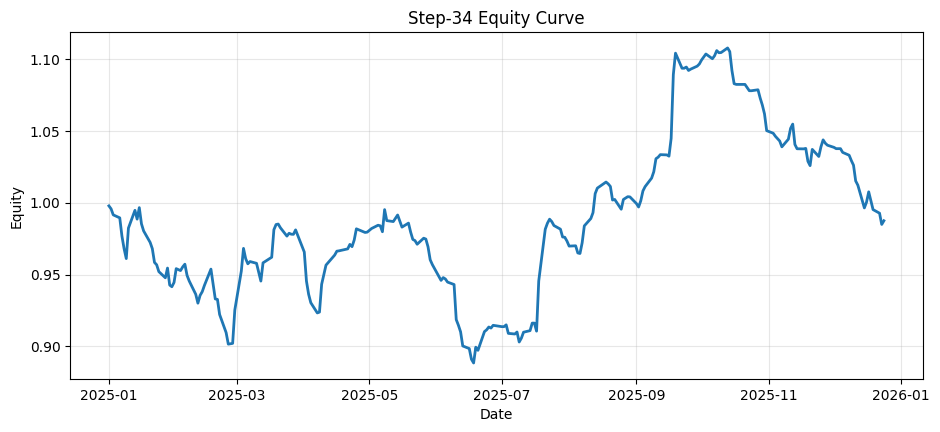

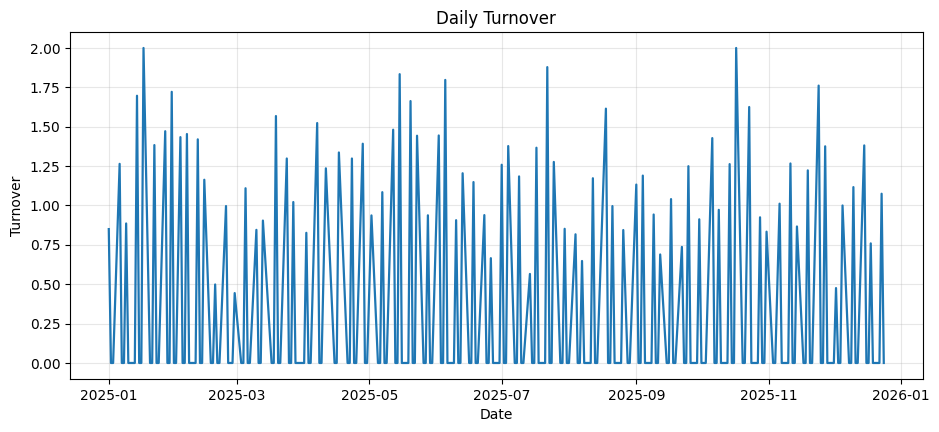

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_13344\359062362.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([reb.dropna(), hold.dropna()], labels=["Rebalance Days", "Hold Days"])


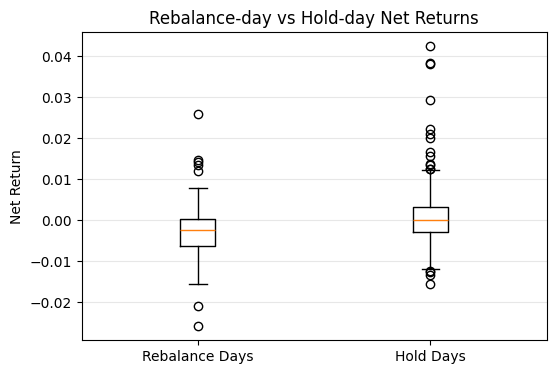

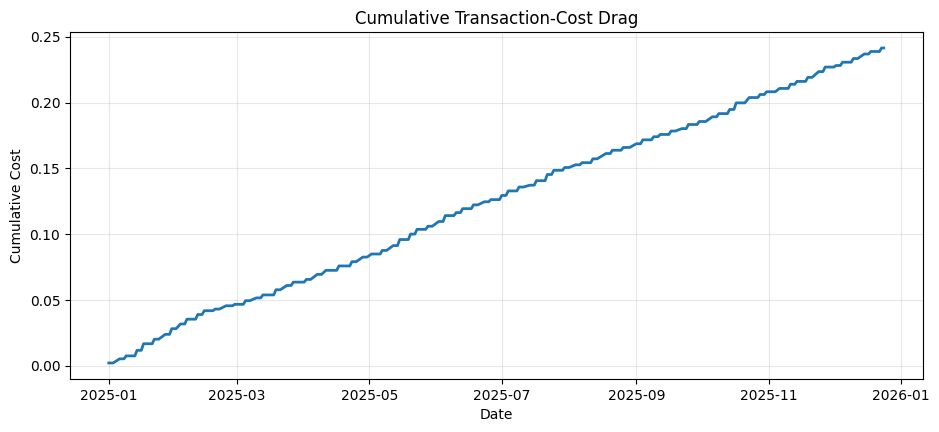

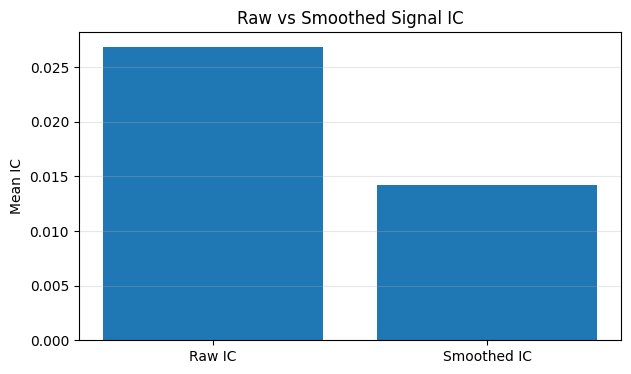

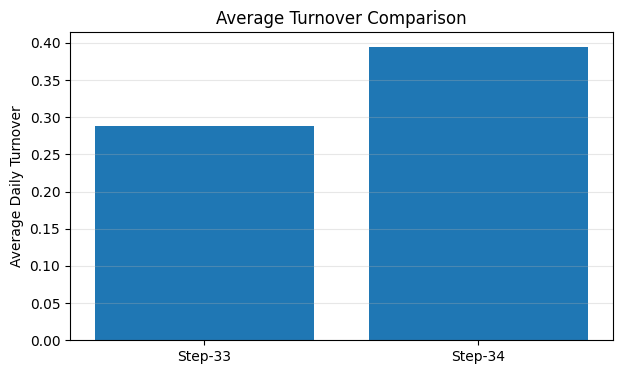

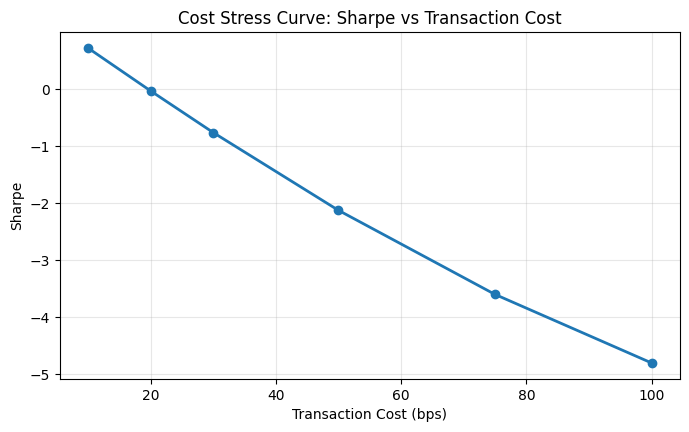

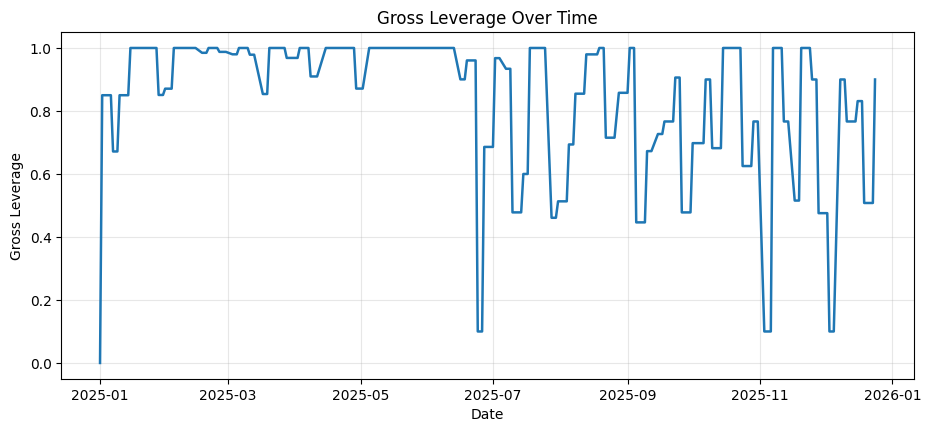

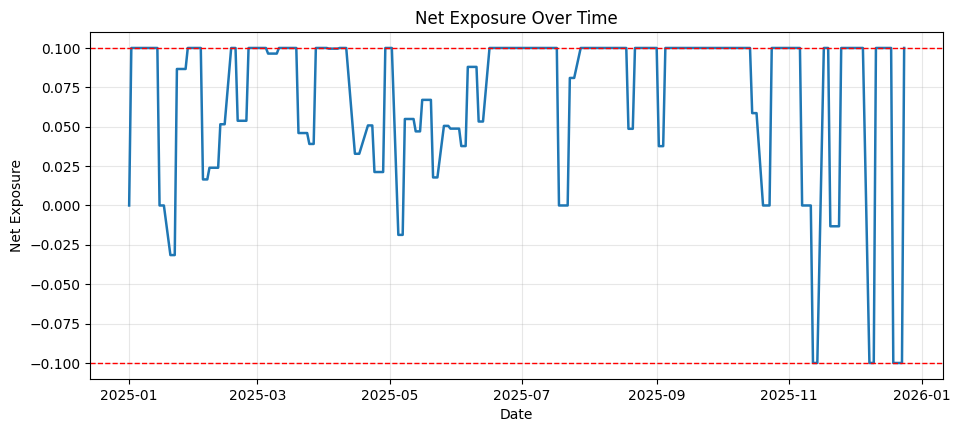

In [9]:
# Visualizations (matplotlib only)
plt.figure(figsize=(11, 4.5))
plt.plot(daily_df["date"], (1 + daily_df["net_return"].fillna(0)).cumprod(), linewidth=2)
plt.title("Step-34 Equity Curve")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(11, 4.5))
plt.plot(daily_df["date"], daily_df["turnover"], linewidth=1.6)
plt.title("Daily Turnover")
plt.xlabel("Date")
plt.ylabel("Turnover")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.boxplot([reb.dropna(), hold.dropna()], labels=["Rebalance Days", "Hold Days"])
plt.title("Rebalance-day vs Hold-day Net Returns")
plt.ylabel("Net Return")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(11, 4.5))
plt.plot(daily_df["date"], daily_df["tx_cost"].cumsum(), linewidth=2)
plt.title("Cumulative Transaction-Cost Drag")
plt.xlabel("Date")
plt.ylabel("Cumulative Cost")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(["Raw IC", "Smoothed IC"], [mean_ic_raw, mean_ic_smooth])
plt.title("Raw vs Smoothed Signal IC")
plt.ylabel("Mean IC")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(["Step-33", "Step-34"], [step33_turn, step34_turn])
plt.title("Average Turnover Comparison")
plt.ylabel("Average Daily Turnover")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(stress_df["tx_bps"], stress_df["sharpe"], marker="o", linewidth=2)
plt.title("Cost Stress Curve: Sharpe vs Transaction Cost")
plt.xlabel("Transaction Cost (bps)")
plt.ylabel("Sharpe")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(11, 4.5))
plt.plot(daily_df["date"], daily_df["gross_leverage"], linewidth=1.8)
plt.title("Gross Leverage Over Time")
plt.xlabel("Date")
plt.ylabel("Gross Leverage")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(11, 4.5))
plt.plot(daily_df["date"], daily_df["net_exposure"], linewidth=1.8)
plt.axhline(CFG["max_net_exposure"], color="red", linestyle="--", linewidth=1)
plt.axhline(-CFG["max_net_exposure"], color="red", linestyle="--", linewidth=1)
plt.title("Net Exposure Over Time")
plt.xlabel("Date")
plt.ylabel("Net Exposure")
plt.grid(True, alpha=0.3)
plt.show()


In [10]:
# Final summary and verdict
summary_df = perf_metrics(daily_df, CFG["annualization_days"])
summary_df = pd.concat(
    [
        summary_df,
        pd.DataFrame(
            [
                ("Mean IC Raw", mean_ic_raw),
                ("Mean IC Smoothed", mean_ic_smooth),
                ("IC Delta Smoothed-Raw", ic_delta),
                ("Avg Rank Corr Raw-Smooth", avg_rank_corr),
                ("Step-33 Avg Turnover", step33_turn),
                ("Step-34 Avg Turnover", step34_turn),
                ("Turnover Reduction %", turnover_reduction_pct),
                ("Rebalance-day Sharpe", reb_sh),
                ("Hold-day Sharpe", hold_sh),
            ],
            columns=["Metric", "Value"],
        ),
    ],
    ignore_index=True,
)

step33_sh = bench_df.loc[bench_df["strategy"] == "Step-33 cost-aware", "sharpe"].iloc[0] if (bench_df["strategy"] == "Step-33 cost-aware").any() else np.nan
step34_sh = bench_df.loc[bench_df["strategy"] == "Step-34 low-turnover", "sharpe"].iloc[0] if (bench_df["strategy"] == "Step-34 low-turnover").any() else np.nan

if pd.notna(step33_sh) and pd.notna(step34_sh) and (step34_turn < 0.10) and (step34_sh > step33_sh + 0.2) and (step34_sh > 0):
    verdict = "PASS"
elif pd.notna(step34_sh) and (step34_sh > step33_sh if pd.notna(step33_sh) else step34_sh > 0):
    verdict = "PARTIAL"
else:
    verdict = "FAIL"

research_conclusion = pd.DataFrame(
    [
        ("Did lower turnover preserve alpha better?", "YES" if pd.notna(step34_sh) and pd.notna(step33_sh) and step34_sh > step33_sh else "NO"),
        ("What was turnover reduction?", turnover_reduction_pct),
        ("How much tx-cost drag eliminated?", float(step33_turn - step34_turn) if pd.notna(step33_turn) else np.nan),
        ("Did smoothing help or hurt?", "HELPED" if pd.notna(ic_delta) and ic_delta >= 0 else "HURT"),
        ("Was periodic rebalancing economically superior?", "YES" if pd.notna(step34_sh) and pd.notna(step33_sh) and step34_sh > step33_sh else "NO"),
        ("Is strategy realistically deployable?", "YES" if verdict in {"PASS", "PARTIAL"} else "NO"),
        ("Final Verdict", verdict),
    ],
    columns=["Question", "Answer"],
)
display(summary_df.round(6))
display(research_conclusion)

print("FINAL VERDICT:", verdict)

# Save outputs
out_port = pos_df.merge(daily_df, on="date", how="left")
out_port.to_parquet(OUT_PORT, index=False)
ic_comp.to_csv(OUT_IC, index=False)
turnover_analysis.to_csv(OUT_TURN, index=False)

summary_export = pd.concat(
    [
        summary_df.rename(columns={"Metric": "Metric", "Value": "Value"}),
        pd.DataFrame({"Metric": research_conclusion["Question"], "Value": research_conclusion["Answer"]}),
    ],
    ignore_index=True,
)
summary_export.to_csv(OUT_SUM, index=False)

print("Saved:")
print("-", OUT_PORT)
print("-", OUT_IC)
print("-", OUT_TURN)
print("-", OUT_SUM)


,Metric,Value
0,Total Return,-0.012473
1,Annualized Return,-0.012760
2,Annualized Volatility,0.133567
3,Sharpe Ratio,-0.030705
4,Max Drawdown,-0.110966
5,Calmar Ratio,-0.114988
6,Win Rate,0.412245
7,Average Turnover,0.394405
8,Average Gross Leverage,0.834613
9,Average Net Exposure,0.068320


,Question,Answer
0,Did lower turnover preserve alpha better?,NO
1,What was turnover reduction?,-0.367197
2,How much tx-cost drag eliminated?,-0.105928
3,Did smoothing help or hurt?,HURT
4,Was periodic rebalancing economically superior?,NO
5,Is strategy realistically deployable?,NO
6,Final Verdict,FAIL


FINAL VERDICT: FAIL
Saved:
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_low_turnover_portfolio.parquet
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_ic_comparison.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_turnover_analysis.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_summary.csv
